<a href="https://colab.research.google.com/github/Mkhalifa8996/Data-Science/blob/main/Multi_class_classification/Multi_class_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing the  data**



In [3]:
import zipfile
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import os, pathlib, random
import matplotlib.image as mpimg
import matplotlib.pyplot as plt


In [4]:
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip

--2026-10-06 08:46:08--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.107.207, 74.125.196.207, 74.125.139.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.107.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 519183241 (495M) [application/zip]
Saving to: ‘10_food_classes_all_data.zip’

10_food_classes_all 100%[===================>] 495.13M   180MB/s    in 2.7s    

2026-10-06 08:46:11 (180 MB/s) - ‘10_food_classes_all_data.zip’ saved [519183241/519183241]



In [5]:
zip_ref = zipfile.ZipFile("/content/10_food_classes_all_data.zip","r")
d = zip_ref.extractall()
zip_ref.close()

In [6]:
# Walk through all 10 classes of food images data
for dirpath, dirnames, filenames in os.walk("/content/10_food_classes_all_data"):
  print(f"There ara {len(dirnames)} folders, and {len(filenames)} files, in {dirpath}")

There ara 2 folders, and 0 files, in /content/10_food_classes_all_data
There ara 10 folders, and 0 files, in /content/10_food_classes_all_data/test
There ara 0 folders, and 250 files, in /content/10_food_classes_all_data/test/grilled_salmon
There ara 0 folders, and 250 files, in /content/10_food_classes_all_data/test/steak
There ara 0 folders, and 250 files, in /content/10_food_classes_all_data/test/ice_cream
There ara 0 folders, and 250 files, in /content/10_food_classes_all_data/test/sushi
There ara 0 folders, and 250 files, in /content/10_food_classes_all_data/test/ramen
There ara 0 folders, and 250 files, in /content/10_food_classes_all_data/test/chicken_wings
There ara 0 folders, and 250 files, in /content/10_food_classes_all_data/test/hamburger
There ara 0 folders, and 250 files, in /content/10_food_classes_all_data/test/fried_rice
There ara 0 folders, and 250 files, in /content/10_food_classes_all_data/test/chicken_curry
There ara 0 folders, and 250 files, in /content/10_food_cl

In [7]:
# Set up the train and test directories
train_dir = "/content/10_food_classes_all_data/train"
test_dir = "/content/10_food_classes_all_data/test"

In [8]:
# Get the class names
data_dir = pathlib.Path(train_dir)
class_names = np.array(sorted([item.name for item in data_dir.glob(pattern="*")]))
print(class_names)

['chicken_curry' 'chicken_wings' 'fried_rice' 'grilled_salmon' 'hamburger'
 'ice_cream' 'pizza' 'ramen' 'steak' 'sushi']


In [33]:
def view_random_image(target_dir, target_class):
  # Define the directory path
  path = target_dir + "/" + target_class
  target_folder = pathlib.Path(path)

  # Get a random image path
  random_img = random.choice(np.array([item.name for item in target_folder.glob(pattern="*")]))

  # Plot the image
  plt.figure(figsize=(7,10))
  img = mpimg.imread( path + "/" + str(random_img))
  print(f"Image name: {random_img},and image shape: {img.shape}")
  plt.axis("off")
  plt.title(target_class)
  plt.imshow(img)

  return img


Image name: 629800.jpg,and image shape: (512, 512, 3)


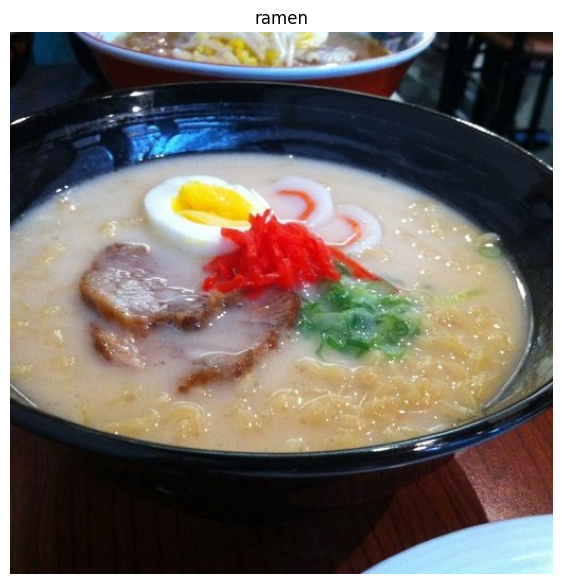

In [34]:
img = view_random_image(train_dir, random.choice(class_names))
